# Línea base activa (secado solar + ventilación forzada)

Semana 5 - "Modelo base validado".

Usa `linea_base_activa.py`: modelo Logarítmico con los parámetros ya
ajustados y publicados por Mackpayen et al. (2017) para un secador solar
de convección forzada (secador Icaro mejorado) — mismo principio físico
(placa absorbedora + ventiladores) que nuestra línea base activa. Ver
`data/reference/mackpayen_2017_icaro_dryer.md` para el detalle completo
de la fuente.

**Nota de unidades:** el paper original define t en minutos; este
notebook trabaja en horas (conversión ya hecha en `linea_base_activa.py`:
k[1/h] = k_paper[1/min] * 60).

In [1]:
import sys
sys.path.append(".")

import numpy as np
import matplotlib.pyplot as plt

from linea_base_activa import (
    mr_linea_base_activa, PARAMETROS_LINEA_ACTIVA,
    T_CAMARA_EQUILIBRIO_C, TIEMPO_MAXIMO_AJUSTE_H,
)
from modelo_secado import PARAMETROS_POR_DEFECTO, curva_secado

## Curva de la línea base activa

Válida con confianza hasta ~8.3 h (rango del ajuste original en el
paper fuente); más allá es extrapolación.

Parametros (ya convertidos a 1/h): ParametrosLogaritmico(a=1.1274, k=0.186, c=-0.178)
Temperatura de camara de equilibrio en la fuente: 54.0 C


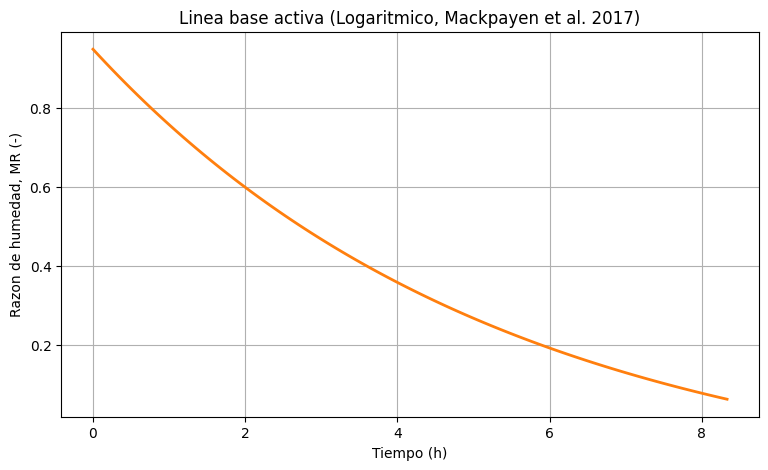

In [2]:
t = np.linspace(0, TIEMPO_MAXIMO_AJUSTE_H, 100)
mr_activa = mr_linea_base_activa(t)

print(f"Parametros (ya convertidos a 1/h): {PARAMETROS_LINEA_ACTIVA}")
print(f"Temperatura de camara de equilibrio en la fuente: {T_CAMARA_EQUILIBRIO_C} C")

plt.figure(figsize=(9, 5))
plt.plot(t, mr_activa, linewidth=2, color="tab:orange")
plt.xlabel("Tiempo (h)")
plt.ylabel("Razon de humedad, MR (-)")
plt.title("Linea base activa (Logaritmico, Mackpayen et al. 2017)")
plt.grid(True)
plt.show()

## Comparación con Midilli modificado (referencia de la propuesta supervisada)

Se grafican en la misma ventana de tiempo (0-8.3 h) para tener una
primera idea comparativa. **Ojo:** los parámetros de Midilli modificado
usados aquí siguen siendo los preliminares de `modelo_secado.py` (no
ajustados todavía a un dataset propio de la propuesta supervisada), así
que esta comparación es solo ilustrativa por ahora, no una conclusión de
desempeño.

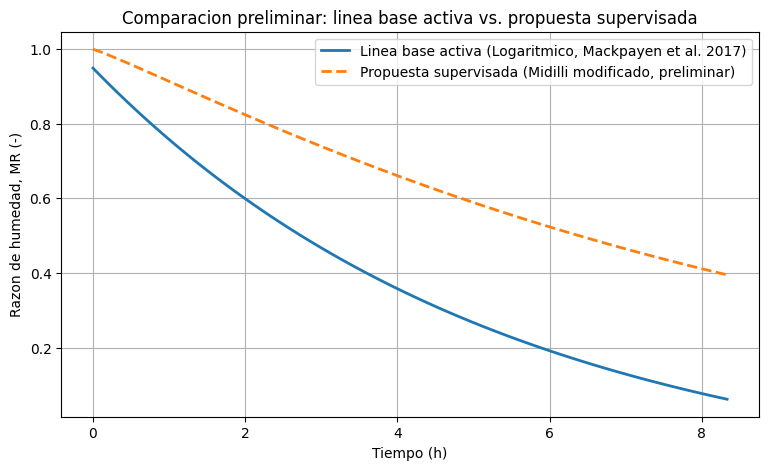

In [3]:
curva_midilli = curva_secado("Midilli_modificado", t)

plt.figure(figsize=(9, 5))
plt.plot(t, mr_activa, linewidth=2, label="Linea base activa (Logaritmico, Mackpayen et al. 2017)")
plt.plot(t, curva_midilli["MR"], "--", linewidth=2, label="Propuesta supervisada (Midilli modificado, preliminar)")
plt.xlabel("Tiempo (h)")
plt.ylabel("Razon de humedad, MR (-)")
plt.title("Comparacion preliminar: linea base activa vs. propuesta supervisada")
plt.legend()
plt.grid(True)
plt.show()

## Próximo paso

Falta el escenario de secado al sol en lazo abierto (línea base mínima,
sin ventilación forzada) para completar el trío de estrategias que se
compararán en la matriz experimental de la semana 7. También queda
pendiente confirmar con el asesor si el diseño térmico final de la línea
base activa del proyecto es comparable al del secador Icaro mejorado
(placa absorbedora con concentración solar) o si conviene ajustar el
modelo a un diseño de menor ganancia térmica.